<a href="https://colab.research.google.com/github/tsarangler/ECON3916-Statistical-Machine-Learning/blob/main/lab%2010/%5BLab_10%5D_Causality_%26_Spurious_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install pandas_datareader
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pandas_datareader import data as pdr
import warnings
warnings.filterwarnings('ignore')

# Define time horizon
start = "2010-01-01"
end = "2024-01-01"

# Fetch a focused set of macro indicators
series = {
    "CPIAUCSL": "cpi",      # Consumer Price Index
    "UNRATE": "unrate",     # Unemployment Rate
    "FEDFUNDS": "fedfunds", # Fed Funds Rate
    "INDPRO": "indpro",     # Industrial Production
    "M2SL": "m2"            # M2 Money Supply
}

# Pull data, normalize to monthly start, and drop NAs
df_list = []
for code, name in series.items():
    s = pdr.DataReader(code, "fred", start, end)
    s.columns = [name]
    df_list.append(s)

df = pd.concat(df_list, axis=1).resample("MS").mean().dropna()
display(df.head())

,cpi,unrate,fedfunds,indpro,m2
DATE,,,,,
2010-01-01,217.488,9.8,0.11,89.3426,8477.7
2010-02-01,217.281,9.8,0.13,89.6779,8527.3
2010-03-01,217.353,9.9,0.16,90.2928,8523.5
2010-04-01,217.403,9.9,0.20,90.5991,8554.8
2010-05-01,217.290,9.6,0.20,91.8230,8609.0


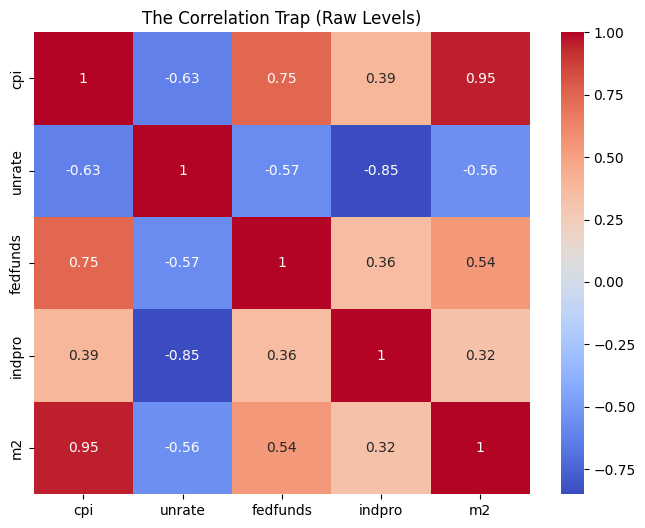

In [2]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("The Correlation Trap (Raw Levels)")
plt.show()

In [3]:

# Step 3

X = df[['unrate', 'fedfunds', 'indpro', 'm2']]
X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

display(vif_data)

,Feature,VIF
0,const,4253.621414
1,unrate,6.206505
2,fedfunds,1.727873
3,indpro,4.291199
4,m2,1.780107


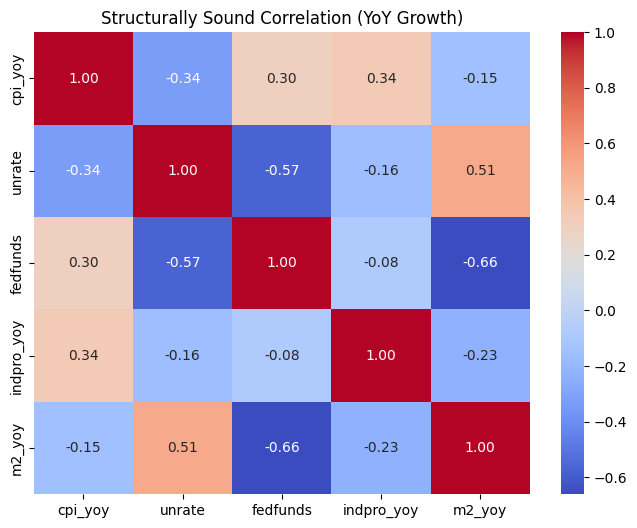

In [4]:
# step 4
df_t = df.copy()

for col in ["cpi", "indpro", "m2"]:
    df_t[f"{col}_yoy"] = 100 * (df_t[col] / df_t[col].shift(12) - 1)


df_t = df_t.dropna()


cols_to_keep = ['cpi_yoy', 'unrate', 'fedfunds', 'indpro_yoy', 'm2_yoy']
plt.figure(figsize=(8, 6))
sns.heatmap(df_t[cols_to_keep].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Structurally Sound Correlation (YoY Growth)")
plt.show()

In [5]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ─────────────────────────────────────────────
# 1. SIMULATE FRED-STYLE DATA
#    Replace this block with your actual DataFrame.
#    Expected columns (raw levels):
#      cpi, unemployment, fed_funds, indpro, m2
#    And YoY growth rate variants:
#      cpi_yoy, unemployment_yoy, fed_funds_yoy, indpro_yoy, m2_yoy
# ─────────────────────────────────────────────
np.random.seed(42)
n = 300  # ~25 years of monthly data

# Simulate integrated (non-stationary) raw level series
# that share a common stochastic trend — this induces
# spurious correlations between unrelated variables.
trend = np.cumsum(np.random.randn(n) * 0.3)

raw = pd.DataFrame({
    "cpi":          np.cumsum(np.random.randn(n) * 0.2 + 0.2) + 100,
    "unemployment": np.clip(5 + np.cumsum(np.random.randn(n) * 0.1), 2, 15),
    "fed_funds":    np.clip(3 + trend * 0.4 + np.random.randn(n) * 0.5, 0, 20),
    "indpro":       np.cumsum(np.random.randn(n) * 0.3 + 0.1) + 100,
    "m2":           np.cumsum(np.random.randn(n) * 0.5 + 0.4) + 1000,
})

# ─────────────────────────────────────────────
# 2. COMPUTE YoY GROWTH RATES
#    pct_change(12) = (x_t - x_{t-12}) / x_{t-12}
#    This differences away the stochastic trend,
#    stationarising the series and removing most
#    spurious long-run correlations.
# ─────────────────────────────────────────────
yoy = raw.pct_change(12).dropna()
yoy.columns = [f"{c}_yoy" for c in yoy.columns]

# ─────────────────────────────────────────────
# 3. COMPUTE CORRELATION MATRICES
# ─────────────────────────────────────────────
labels_raw = ["CPI", "Unemployment", "Fed Funds", "Ind. Production", "M2"]
labels_yoy = [f"{l} YoY" for l in labels_raw]

corr_raw = raw.corr().values          # 5×5 numpy array
corr_yoy = yoy.corr().values          # 5×5 numpy array (after dropna aligns rows)

# ─────────────────────────────────────────────
# 4. HELPER: build annotation text matrix
#    Rounds each value to 2 decimal places for
#    clean display inside heatmap cells.
# ─────────────────────────────────────────────
def annotation_text(matrix):
    return [[f"{v:.2f}" for v in row] for row in matrix]

# ─────────────────────────────────────────────
# 5. BUILD THE FIGURE
#    We add BOTH heatmap traces upfront, then use
#    updatemenus to toggle visibility between them.
#    This is faster than re-rendering on each click.
# ─────────────────────────────────────────────
fig = go.Figure()

# ── Trace 0: Raw levels correlation matrix ──
fig.add_trace(go.Heatmap(
    z=corr_raw,
    x=labels_raw,
    y=labels_raw,
    text=annotation_text(corr_raw),   # cell annotations
    texttemplate="%{text}",           # display the text strings
    textfont={"size": 13, "color": "black"},
    colorscale="RdBu",
    zmin=-1, zmax=1,                  # fix scale so both views are comparable
    reversescale=True,                # blue = positive, red = negative (intuitive)
    showscale=True,
    colorbar=dict(title="r", tickvals=[-1, -0.5, 0, 0.5, 1]),
    visible=True,                     # shown by default
    name="Raw Levels",
))

# ── Trace 1: YoY growth rates correlation matrix ──
fig.add_trace(go.Heatmap(
    z=corr_yoy,
    x=labels_yoy,
    y=labels_yoy,
    text=annotation_text(corr_yoy),
    texttemplate="%{text}",
    textfont={"size": 13, "color": "black"},
    colorscale="RdBu",
    zmin=-1, zmax=1,
    reversescale=True,
    showscale=True,
    colorbar=dict(title="r", tickvals=[-1, -0.5, 0, 0.5, 1]),
    visible=False,                    # hidden until selected
    name="YoY Growth Rates",
))

# ─────────────────────────────────────────────
# 6. DROPDOWN MENU via updatemenus
#
#    Each button carries an `args` list that is
#    passed to Plotly's `restyle` command under
#    the hood (see architecture section below).
#    We toggle visibility of the two traces and
#    update the title simultaneously.
# ─────────────────────────────────────────────
fig.update_layout(
    updatemenus=[
        dict(
            type="dropdown",          # renders as an HTML <select>-style menu
            direction="down",
            x=0.0, y=1.15,           # position: top-left above the chart
            xanchor="left",
            showactive=True,
            bgcolor="white",
            bordercolor="lightgray",
            font=dict(size=13),
            buttons=[
                dict(
                    label="Raw Levels",
                    method="update",  # calls both restyle + relayout
                    args=[
                        # arg[0] → restyle: trace property updates
                        {"visible": [True, False]},
                        # arg[1] → relayout: layout property updates
                        {"title.text": "Correlation Matrix — Raw Levels (Spurious Correlations Present)"},
                    ],
                ),
                dict(
                    label="YoY Growth Rates",
                    method="update",
                    args=[
                        {"visible": [False, True]},
                        {"title.text": "Correlation Matrix — YoY Growth Rates (Spurious Correlations Reduced)"},
                    ],
                ),
            ],
        )
    ],
    title=dict(
        text="Correlation Matrix — Raw Levels (Spurious Correlations Present)",
        font=dict(size=16),
        x=0.5,
    ),
    width=680,
    height=620,
    margin=dict(t=120, l=120, r=40, b=80),
    xaxis=dict(tickangle=-30, tickfont=dict(size=11)),
    yaxis=dict(tickfont=dict(size=11)),
    paper_bgcolor="white",
    plot_bgcolor="white",
)

fig.show()
# Optional: fig.write_html("macro_heatmap.html")